# Proyecto final DataXperience - Gastos personales

# Fase 1 - Fundamentos y Preparación del Dataset de Gastos Personales


## Introducción

El presente proyecto aborda el análisis financiero de los patrones de gasto personales mediante el flujo de trabajo estándar en Ciencia de Datos. Como parte del Módulo 1: Fundamentos y Preparación de Datos, esta etapa inicial se enfoca en la recolección, exploración, depuración y estructuración de la información. El objetivo técnico es garantizar la calidad e integridad de los datos para servir como base confiable a las posteriores fases de análisis estadístico descriptivo y visualización.


## Objetivo Principal del Dataset

Estructurar y limpiar un conjunto de datos estandarizado sobre transacciones financieras diarias que abarque el primer trimestre del año 2025 (01 de enero de 2025 al 31 de marzo de 2025), permitiendo categorizar los hábitos de consumo, identificar tipos de gastos y evaluar el uso de los diferentes medios de pago.


## Origen y Organización de los Datos

### Fuente de los Datos

> Los datos base provienen del dataset público de Kaggle titulado [**`Hostel Life Daily Expense Tracker (Jan-Mar 2025)`**](https://www.kaggle.com/datasets/kagglecombharathi/hostel-life-daily-expense-tracker-janmar-2025), el cual recopila registros transaccionales en un contexto educativo de administración de presupuesto.

### Aclaración Metodológica (Acondicionamiento de Datos)

> **Nota sobre el acondicionamiento del dataset:**  
> Con fines pedagógicos y para cumplir con los requerimientos de evaluación del Módulo 1, la muestra original fue intencionalmente acondicionada mediante la inyección controlada de inconsistencias típicas de la vida real (variaciones en el formato de texto, inconsistencias en el registro de fechas y valores faltantes). Esto permite evidenciar de forma práctica la aplicación de técnicas de Data Wrangling y limpieza con la librería Pandas en Python.


## Estructura de las Variables

El dataset procesado organiza la información en las siguientes columnas clave atómicas y normalizadas:

| Nombre de Columna | Tipo de Dato Objetivo | Descripción / Qué representa | Ejemplo de Registro |
| :--- | :--- | :--- | :--- |
| **`date`** | `datetime64` | Fecha en la que se realizó la transacción (Rango: 2025-01-01 a 2025-03-31). | `2025-01-15` |
| **`expense_type`** | `string / category` | Categoría principal o tipo de gasto (ej. Food, Travel, Bills). | `Food` |
| **`amount`** | `float64` | Monto o valor numérico pagado en la transacción. | `25.0` |
| **`payment_mode`** | `string / category` | Medio o canal de pago utilizado (ej. Cash, Card, UPI, Transfer). | `Cash` |
| **`notes`** | `string` | Detalle, especificación o descripción breve de la compra. | `Pen refill` |
| **`type`** *(Creada)* | `category` | Clasificación del gasto en función de su recurrencia (`Fixed` vs `Variable`). | `Variable` |
| **`necessity`** *(Creada)* | `category` | Prioridad del gasto para el presupuesto (`Necessary` vs `Discretionary`). | `Necessary` |

## Plan de Limpieza y Transformación

El flujo de preprocesamiento se ejecutará en 5 pasos clave dentro de Python:

1. **Carga e Inspección:** Configuración del entorno en Colab, montaje de Google Drive y consolidación de columnas desalineadas (`Date` vs `date`).
2. **Depuración de Duplicados y Fechas:** Eliminación de registros idénticos repetidos (`drop_duplicates()`), estandarización de la columna `date` a `datetime64` y manejo de fechas corruptas/inválidas (`NaT`).
3. **Saneamiento Numérico y Categorizado:** Remoción de símbolos monetarios (`$`) en `amount` para su conversión a numérico (`float64`), junto con la eliminación de espacios y mapeo de sinónimos al inglés en `expense_type`.
4. **Tratamiento de Nulos y Outliers:** Imputación categórica de valores faltantes (`Cash` para medio de pago y `No description` para notas), eliminación de filas sin monto o fecha, y filtrado de gastos atípicos por errores de digitación (< 1,000,000).
5. **Enriquecimiento y Exportación:** Derivación de las columnas de negocio en inglés **`type`** (`Fixed`/`Variable`) y **`necessity`** (`Necessary`/`Discretionary`), guardando el archivo depurado en `hostel_life_expense_tracker_cleaned.csv`.

### 1 Carga del Dataset y Exploración Inicial de Datos

En esta primera fase se establece la conexión con Google Drive y se configura el acceso a la carpeta `data` compartida. Se realiza la carga directa del dataset [`hostel_life_expense_tracker.csv`](https://drive.google.com/file/d/1ZtXA6w079gVogv4r8a_eRcsg1pq5NSXr/view?usp=drive_link) dentro del entorno de trabajo de Google Colab para inspeccionar sus dimensiones, tipos de datos y la visualización tabular preliminar de los registros sin realizar ninguna modificación ni depuración a la matriz original.

In [2]:
import os
import pandas as pd
from google.colab import drive
from IPython.display import display

# 1. Montar Google Drive (ignora limpiamente si ya está montado)
try:
    drive.mount('/content/drive')
except Exception:
    pass

# 2. Configurar directorio de trabajo y ruta del dataset
data_dir = '/content/drive/MyDrive/data'
raw_file_path = os.path.join(data_dir, 'hostel_life_expense_tracker.csv')

# 3. Cargar el dataset en el espacio de trabajo
df_raw = pd.read_csv(raw_file_path)

# 4. Mostrar información general de dimensiones y tipos de datos
print(f" DATASET CARGADO CORRECTAMENTE EN EL ESPACIO DE TRABAJO")
print(f" Ruta de acceso: {raw_file_path}")
print(f" Dimensiones iniciales (Filas, Columnas): {df_raw.shape}")

print("Resumen de Estructura de Tipos de Datos (df_raw.info())")
df_raw.info()

print("\n--- Muestra Tabular de las Primeras 5 Filas Cargadas ---")
display(df_raw.head(5))

Mounted at /content/drive
 DATASET CARGADO CORRECTAMENTE EN EL ESPACIO DE TRABAJO
 Ruta de acceso: /content/drive/MyDrive/data/hostel_life_expense_tracker.csv
 Dimensiones iniciales (Filas, Columnas): (198, 9)
Resumen de Estructura de Tipos de Datos (df_raw.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                190 non-null    object 
 1   Expense_Type        190 non-null    object 
 2   Amount              190 non-null    float64
 3   Payment_Mode        190 non-null    object 
 4   Notes               190 non-null    object 
 5   date                8 non-null      object 
 6   expense_type        7 non-null      object 
 7   amount              7 non-null      object 
 8   payment_mode_notes  7 non-null      object 
dtypes: float64(1), object(8)
memory usage: 14.1+ KB

--- Muestra Tabular de las Primeras 5

,Date,Expense_Type,Amount,Payment_Mode,Notes,date,expense_type,amount,payment_mode_notes
0,2025-01-23,Stationary,25.0,Cash,Pen refill,NaN,NaN,NaN,NaN
1,2025-02-09,Travel,25.0,Cash,Bus ticket,NaN,NaN,NaN,NaN
2,2025-01-06,Travel,18.0,UPI,Bus ride,NaN,NaN,NaN,NaN
3,2025-02-18,Stationary,45.0,Cash,Drawing sheets,NaN,NaN,NaN,NaN
4,2025-02-27,Medical,120.0,UPI,Cold tablet,NaN,NaN,NaN,NaN


### 2. Consolidación Estructural y Normalización de Datos


#### 2.1. Consolidación de Columnas Desalineadas

**Problema:** Debido a diferencias de caja en los encabezados (`Date` vs `date`, `Amount` vs `amount`), la matriz presenta 9 columnas con valores faltantes (`NaN`) cruzados.

**Solución:** Se aplica la función `combine_first()` para fusionar los datos en una estructura atómica de 5 columnas normalizadas.

In [3]:
df_fase2 = df_raw.copy()

# Consolidar columnas duplicadas por diferencia de mayúsculas/minúsculas mediante combine_first
if 'Date' in df_fase2.columns:
    df_fase2['date'] = df_fase2['date'].combine_first(df_fase2['Date']) if 'date' in df_fase2.columns else df_fase2['Date']
    df_fase2['expense_type'] = df_fase2['expense_type'].combine_first(df_fase2['Expense_Type']) if 'expense_type' in df_fase2.columns else df_fase2['Expense_Type']
    df_fase2['amount'] = df_fase2['amount'].combine_first(df_fase2['Amount']) if 'amount' in df_fase2.columns else df_fase2['Amount']
    df_fase2['payment_mode'] = df_fase2['payment_mode'].combine_first(df_fase2['Payment_Mode']) if 'payment_mode' in df_fase2.columns else df_fase2['Payment_Mode']
    df_fase2['notes'] = df_fase2['notes'].combine_first(df_fase2['Notes']) if 'notes' in df_fase2.columns else df_fase2['Notes']

# Retener únicamente las 5 columnas atómicas y normalizadas en snake_case
df_fase2 = df_fase2[['date', 'expense_type', 'amount', 'payment_mode', 'notes']]

print(f"Dimensiones consolidadas: {df_fase2.shape}")
print("\n--- Muestra de Registros Consolidados a 5 Columnas Atómicas ---")
display(df_fase2.head(8))

Dimensiones consolidadas: (198, 5)

--- Muestra de Registros Consolidados a 5 Columnas Atómicas ---


,date,expense_type,amount,payment_mode,notes
0,2025-01-23,Stationary,25.0,Cash,Pen refill
1,2025-02-09,Travel,25.0,Cash,Bus ticket
2,2025-01-06,Travel,18.0,UPI,Bus ride
3,2025-02-18,Stationary,45.0,Cash,Drawing sheets
4,2025-02-27,Medical,120.0,UPI,Cold tablet
5,2025-02-13,Travel,22.0,Cash,Bus ticket
6,2025-02-17,Food,100.0,UPI,Dosai
7,2025-01-11,Snacks,30.0,UPI,Puffs


#### 2.2 Depuración de Duplicados Exactos

**Problema:** Se detectó la presencia de registros idénticos repetidos en la muestra, inyectados sintéticamente para simular errores de captura o sobreescritura de datos.

**Solución:** Se realiza la identificación explícita de las filas duplicadas mediante `duplicated(keep=False)` para visualizarlas en una tabla de control, y posteriormente se remueven de forma definitiva del DataFrame con `drop_duplicates()`, restableciendo los índices.

In [4]:
# 1. Identificar registros duplicados exactos antes de removerlos
duplicados_df = df_fase2[df_fase2.duplicated(keep=False)]

print(f"Total de registros duplicados exactos detectados: {df_fase2.duplicated().sum()}")
print("\n Muestra de Registros Duplicados Detectados en el Dataset")
display(duplicados_df.head(6))

# 2. Eliminar duplicados exactos y reindexar
df_fase2 = df_fase2.drop_duplicates().reset_index(drop=True)

print(f"\n Total de filas tras remover duplicados: {len(df_fase2)}")

Total de registros duplicados exactos detectados: 2

 Muestra de Registros Duplicados Detectados en el Dataset


,date,expense_type,amount,payment_mode,notes
22,2025-01-21,Snacks,40.0,Cash,Chips
68,2025-01-01,Snacks,40.0,Cash,Bought biscuits
100,2025-01-01,Snacks,40.0,Cash,Bought biscuits
122,2025-01-21,Snacks,40.0,Cash,Chips



 Total de filas tras remover duplicados: 196


#### 2.3 Conversión y Manejo de Fechas Incoherentes (`date`)

**Problema:** Inconsistencias en los formatos de fecha y presencia de registros corruptos o fuera de rango (ej. `2025-03-99`), inyectados para evaluar el control de excepciones temporales.

**Solución:** Conversión al tipo de dato `datetime64` mediante `pd.to_datetime()`. Se utiliza el parámetro `errors='coerce'` para forzar que cualquier fecha inviable se transforme en una constante `NaT` (*Not a Time*), aislándola en una tabla de control para su posterior depuración en la fase de nulos.

In [5]:
# 1. Convertir la columna date a tipo datetime64 forzando errores a NaT
df_fase2['date'] = pd.to_datetime(df_fase2['date'], errors='coerce')

# 2. Filtrar y aislar los registros con fechas corruptas/fuera de rango (NaT)
fechas_invalidas_df = df_fase2[df_fase2['date'].isnull()]

print(f"Total de registros con fechas incoherentes transformados a NaT: {len(fechas_invalidas_df)}")
print(f"Tipo de dato final en la columna 'date': {df_fase2['date'].dtype}\n")

print("Muestra de Registros con Fechas Incoherentes Convertidas a NaT")
display(fechas_invalidas_df)

Total de registros con fechas incoherentes transformados a NaT: 2
Tipo de dato final en la columna 'date': datetime64[ns]

Muestra de Registros con Fechas Incoherentes Convertidas a NaT


,date,expense_type,amount,payment_mode,notes
53,NaT,Bills,45000,NaN,NaN
125,NaT,Transporte,12000,NaN,NaN


#### 2.4 Depuración Numérica de Montos (`amount`)

**Problema:** Los valores monetarios de la columna `amount` presentan caracteres especiales de texto (como el símbolo `$` o comas `,`), impidiendo su procesamiento matemático y su conversión a tipo continuo.

**Solución:** Se identifican y muestran los registros específicos afectados antes del filtrado. Posteriormente, se remueven los caracteres especiales de texto mediante `.str.replace()` y se convierte la variable explícitamente a tipo numérico continuo (`float64`) con `pd.to_numeric()`.

In [6]:
# 1. Identificar cuáles registros contienen '$' o ',' antes de modificarlos
registros_con_caracteres = df_fase2[
    df_fase2['amount'].astype(str).str.contains(r'[\$,]', regex=True, na=False)
]

print(f" Total de registros con caracteres especiales ('$' o ','): {len(registros_con_caracteres)}")
print("Registros Específicos Afectados con Símbolos de Texto")
display(registros_con_caracteres)

# 2. Aplicar la limpieza de caracteres especiales y conversión a float64
df_fase2['amount'] = df_fase2['amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_fase2['amount'] = pd.to_numeric(df_fase2['amount'], errors='coerce')

# 3. Métricas exactas del procesamiento
total_procesados = len(df_fase2)

print(f"Registros totales procesados: {total_procesados}")
print(f"Tipo de dato final en la columna 'amount': {df_fase2['amount'].dtype}")

print("Muestra de los Registros Procesados con Montos Limpios")
display(df_fase2.head(10))

 Total de registros con caracteres especiales ('$' o ','): 1
Registros Específicos Afectados con Símbolos de Texto


,date,expense_type,amount,payment_mode,notes
187,2025-03-12,Health,"$50,000",NaN,NaN


Registros totales procesados: 196
Tipo de dato final en la columna 'amount': float64
Muestra de los Registros Procesados con Montos Limpios


,date,expense_type,amount,payment_mode,notes
0,2025-01-23,Stationary,25.0,Cash,Pen refill
1,2025-02-09,Travel,25.0,Cash,Bus ticket
2,2025-01-06,Travel,18.0,UPI,Bus ride
3,2025-02-18,Stationary,45.0,Cash,Drawing sheets
4,2025-02-27,Medical,120.0,UPI,Cold tablet
5,2025-02-13,Travel,22.0,Cash,Bus ticket
6,2025-02-17,Food,100.0,UPI,Dosai
7,2025-01-11,Snacks,30.0,UPI,Puffs
8,2025-01-07,Health,60.0,UPI,Vitamin tablets
9,2025-03-10,Snacks,20.0,Cash,Samosa


### 3. Saneamiento y Normalización Categórica de Texto

#### 3.1 Detección de Inconsistencias y Mapeo de Categorías

**Problema:** La columna `expense_type` contiene inconsistencias por espacios en blanco sobrantes, combinaciones inadecuadas de mayúsculas/minúsculas y uso de sinónimos tanto en español como en inglés (ej. `alimentacion`, `Comida`, `Food`, `Transporte`).

**Solución:** Se remueven los espacios de formato con `.str.strip()`, se aplica capitalización uniforme en *Title Case* y se realiza la sustitución de sinónimos mediante un diccionario de mapeo categórico alineado al estándar en inglés.

In [7]:
# Crear copia de trabajo para la Fase 3 a partir de la fase anterior
df_fase3 = df_fase2.copy()

# 1. Visualizar frecuencia de categorías originales antes de limpiar
cat_originales = df_fase3['expense_type'].value_counts(dropna=False).reset_index()
cat_originales.columns = ['Categoría Original', 'Frecuencia Inicial']

print(" Categorías detectadas antes del saneamiento:")
display(cat_originales)

# 2. Remover espacios sobrantes y aplicar Title Case
df_fase3['expense_type'] = df_fase3['expense_type'].astype(str).str.strip().str.title()

# 3. Mapeo de sinónimos al estándar en inglés
category_mapping = {
    'Alimentacion': 'Food',
    'Comida': 'Food',
    'Transporte': 'Travel',
    'Servicios': 'Bills'
}
df_fase3['expense_type'] = df_fase3['expense_type'].replace(category_mapping)

 Categorías detectadas antes del saneamiento:


,Categoría Original,Frecuencia Inicial
0,Snacks,59
1,Food,47
2,Travel,34
3,Stationary,21
4,Laundry,16
5,Health,9
6,Medical,3
7,Transporte,2
8,comida,1
9,Bills,1


#### 3.2 Consolidación de la Variable Categórica `expense_type`

**Objetivo:** Validar la reducción de inconsistencias y la unificación de los registros en un número finito de categorías estándar.

**Resultado:** Se consolida la distribución categórica, eliminando la duplicidad léxica y garantizando datos atómicos para los análisis comparativos.

In [8]:
# 1. Obtener la distribución final de categorías homogeneizadas
cat_limpias = df_fase3['expense_type'].value_counts().reset_index()
cat_limpias.columns = ['Categoría Normalizada', 'Frecuencia Final']

print(f" Registros totales procesados: {len(df_fase3)}")
print(f" Número de categorías únicas normalizadas: {len(cat_limpias)}\n")

print("Tabla de Resumen: Frecuencia de Categorías Estandarizadas")
display(cat_limpias)

print("\n--- Muestra de Registros con Categorías Normalizadas ---")
display(df_fase3.head(10))

 Registros totales procesados: 196
 Número de categorías únicas normalizadas: 10

Tabla de Resumen: Frecuencia de Categorías Estandarizadas


,Categoría Normalizada,Frecuencia Final
0,Snacks,59
1,Food,49
2,Travel,36
3,Stationary,21
4,Laundry,16
5,Health,9
6,Medical,3
7,Bills,1
8,Entertainment,1
9,Nan,1



--- Muestra de Registros con Categorías Normalizadas ---


,date,expense_type,amount,payment_mode,notes
0,2025-01-23,Stationary,25.0,Cash,Pen refill
1,2025-02-09,Travel,25.0,Cash,Bus ticket
2,2025-01-06,Travel,18.0,UPI,Bus ride
3,2025-02-18,Stationary,45.0,Cash,Drawing sheets
4,2025-02-27,Medical,120.0,UPI,Cold tablet
5,2025-02-13,Travel,22.0,Cash,Bus ticket
6,2025-02-17,Food,100.0,UPI,Dosai
7,2025-01-11,Snacks,30.0,UPI,Puffs
8,2025-01-07,Health,60.0,UPI,Vitamin tablets
9,2025-03-10,Snacks,20.0,Cash,Samosa


### 4. Tratamiento de Valores Faltantes (NaN) y Outliers
#### 4.1 Imputación Categórica de Valores Faltantes

**Problema:** Presencia de valores nulos (`NaN`) en variables cualitativas como `payment_mode` y `notes`.

**Solución:** Imputación de negocio conservadora asignando el medio de pago por defecto `'Cash'` a los registros faltantes en `payment_mode` y la etiqueta `'No description'` para las descripciones ausentes en `notes`.

In [9]:
# Crear copia de trabajo para la Fase 4
df_fase4 = df_fase3.copy()

# 1. Identificar registros con nulos en payment_mode o notes antes de imputar
nulos_categoricos = df_fase4[df_fase4['payment_mode'].isnull() | df_fase4['notes'].isnull()]

print(f" Registros con nulos en variables categóricas: {len(nulos_categoricos)}")
print("Muestra de Registros con Nulos en Categorías")
display(nulos_categoricos)

# 2. Imputación
df_fase4['payment_mode'] = df_fase4['payment_mode'].fillna('Cash')
df_fase4['notes'] = df_fase4['notes'].fillna('No description')
df_fase4['expense_type'] = df_fase4['expense_type'].replace({'Nan': 'Otros', 'None': 'Otros'})

 Registros con nulos en variables categóricas: 8
Muestra de Registros con Nulos en Categorías


,date,expense_type,amount,payment_mode,notes
35,2025-02-10,Food,18000.0,NaN,NaN
53,NaT,Bills,45000.0,NaN,NaN
76,2025-02-28,Entertainment,NaN,NaN,NaN
125,NaT,Travel,12000.0,NaN,NaN
147,2025-03-05,Travel,99999999.0,NaN,NaN
164,2025-01-20,Nan,35000.0,NaN,NaN
171,2025-01-15,Food,25.0,NaN,NaN
187,2025-03-12,Health,50000.0,NaN,NaN


#### 4.2 Remoción de Filas con Valores Faltantes Críticos

**Problema:** Existencia de registros que carecen de fecha válida (`NaT`) o de monto (`NaN`), los cuales no pueden ser imputados sin sesgar el análisis temporal y financiero.

**Solución:** Descarte definitivo de estas filas mediante `dropna(subset=['date', 'amount'])`.

In [10]:
# 1. Identificar filas con nulos en date o amount
nulos_criticos = df_fase4[df_fase4['date'].isnull() | df_fase4['amount'].isnull()]

print(f" Total de filas con nulos críticos (sin fecha o monto): {len(nulos_criticos)}")
print("Registros Incompletos a Descartar")
display(nulos_criticos)

# 2. Descartar filas y reindexar
df_fase4 = df_fase4.dropna(subset=['date', 'amount']).reset_index(drop=True)

 Total de filas con nulos críticos (sin fecha o monto): 3
Registros Incompletos a Descartar


,date,expense_type,amount,payment_mode,notes
53,NaT,Bills,45000.0,Cash,No description
76,2025-02-28,Entertainment,NaN,Cash,No description
125,NaT,Travel,12000.0,Cash,No description


#### 4.3 Identificación y Remoción de Outliers Extremos

**Problema:** Detección de valores atípicos severos en la columna `amount` originados por errores de digitación en la entrada de datos (ej. montos superiores a 1,000,000).

**Solución:** Filtrado lógico estableciendo un umbral superior para excluir estos errores antes del análisis descriptivo.

In [11]:
# 1. Identificar registros atípicos según el umbral
umbral = 1000000
outliers_df = df_fase4[df_fase4['amount'] >= umbral]

print(f" Outliers extremos detectados (Monto >= {umbral:,}): {len(outliers_df)}")
print("Registros Atípicos Detectados")
display(outliers_df)

# 2. Filtrar outliers
df_fase4 = df_fase4[df_fase4['amount'] < umbral].reset_index(drop=True)

print(f"\n Matriz final depurada: {len(df_fase4)} filas.")
print("\n--- Muestra de Registros Tras Tratamiento de Nulos y Outliers ---")
display(df_fase4.head(10))

 Outliers extremos detectados (Monto >= 1,000,000): 1
Registros Atípicos Detectados


,date,expense_type,amount,payment_mode,notes
144,2025-03-05,Travel,99999999.0,Cash,No description



 Matriz final depurada: 192 filas.

--- Muestra de Registros Tras Tratamiento de Nulos y Outliers ---


,date,expense_type,amount,payment_mode,notes
0,2025-01-23,Stationary,25.0,Cash,Pen refill
1,2025-02-09,Travel,25.0,Cash,Bus ticket
2,2025-01-06,Travel,18.0,UPI,Bus ride
3,2025-02-18,Stationary,45.0,Cash,Drawing sheets
4,2025-02-27,Medical,120.0,UPI,Cold tablet
5,2025-02-13,Travel,22.0,Cash,Bus ticket
6,2025-02-17,Food,100.0,UPI,Dosai
7,2025-01-11,Snacks,30.0,UPI,Puffs
8,2025-01-07,Health,60.0,UPI,Vitamin tablets
9,2025-03-10,Snacks,20.0,Cash,Samosa


### 5. Enriquecimiento del Dataset y Exportación Final
#### 5.1 Derivación de Variables Categóricas de Negocio

**Objetivo:** Enriquecer el dataset añadiendo dos variables cualitativas estructuradas que permitan análisis presupuestarios más profundos:

* **`type`:** Clasificación en función de la recurrencia del gasto (`Fixed` para costos recurrentes/obligatorios y `Variable` para consumo cotidiano).
* **`necessity`:** Clasificación de prioridad presupuestaria (`Necessary` para necesidades básicas y `Discretionary` para consumos prescindibles).

In [12]:
# Crear copia de trabajo para la Fase 5
df_fase5 = df_fase4.copy()

# 1. Listas categóricas para reglas de negocio
fixed_categories = ['Bills', 'Study', 'Rent', 'Medical', 'Health', 'Stationary']
discretionary_categories = ['Entertainment', 'Shopping', 'Snacks']

# 2. Derivar la columna 'type'
df_fase5['type'] = df_fase5['expense_type'].apply(
    lambda x: 'Fixed' if any(k in str(x) for k in fixed_categories) else 'Variable'
)

# 3. Derivar la columna 'necessity'
df_fase5['necessity'] = df_fase5['expense_type'].apply(
    lambda x: 'Discretionary' if any(k in str(x) for k in discretionary_categories) else 'Necessary'
)

print("Variables 'type' y 'necessity' creadas exitosamente.\n")

print("Distribución de Gastos por Recurrencia ('type')")
display(df_fase5['type'].value_counts().reset_index())

print("\n--- Distribución de Gastos por Prioridad ('necessity') ---")
display(df_fase5['necessity'].value_counts().reset_index())

Variables 'type' y 'necessity' creadas exitosamente.

Distribución de Gastos por Recurrencia ('type')


,type,count
0,Variable,159
1,Fixed,33



--- Distribución de Gastos por Prioridad ('necessity') ---


,necessity,count
0,Necessary,133
1,Discretionary,59


#### 5.2 Guardado y Exportación de la Matriz Depurada

**Objetivo:** Almacenar de forma permanente el dataset procesado y enriquecido en la carpeta `data` de Google Drive en formato CSV, asegurando la disponibilidad de los datos limpios para las posteriores fases del proyecto.

In [13]:
# Ruta de exportación final en Google Drive
clean_file_path = os.path.join(data_dir, 'hostel_life_expense_tracker_cleaned.csv')

# Guardar DataFrame final
df_fase5.to_csv(clean_file_path, index=False)

print(" ¡PROCESO DE LIMPIEZA COMPLETO Y EXITOSO!")
print(f" Dataset exportado a: {clean_file_path}")
print(f" Dimensiones finales (Filas, Columnas): {df_fase5.shape}")

print("MUESTRA FINAL DE LA MATRIZ DEPURADA (PRIMEROS 10 REGISTROS)")
display(df_fase5.head(10))

 ¡PROCESO DE LIMPIEZA COMPLETO Y EXITOSO!
 Dataset exportado a: /content/drive/MyDrive/data/hostel_life_expense_tracker_cleaned.csv
 Dimensiones finales (Filas, Columnas): (192, 7)
MUESTRA FINAL DE LA MATRIZ DEPURADA (PRIMEROS 10 REGISTROS)


,date,expense_type,amount,payment_mode,notes,type,necessity
0,2025-01-23,Stationary,25.0,Cash,Pen refill,Fixed,Necessary
1,2025-02-09,Travel,25.0,Cash,Bus ticket,Variable,Necessary
2,2025-01-06,Travel,18.0,UPI,Bus ride,Variable,Necessary
3,2025-02-18,Stationary,45.0,Cash,Drawing sheets,Fixed,Necessary
4,2025-02-27,Medical,120.0,UPI,Cold tablet,Fixed,Necessary
5,2025-02-13,Travel,22.0,Cash,Bus ticket,Variable,Necessary
6,2025-02-17,Food,100.0,UPI,Dosai,Variable,Necessary
7,2025-01-11,Snacks,30.0,UPI,Puffs,Variable,Discretionary
8,2025-01-07,Health,60.0,UPI,Vitamin tablets,Fixed,Necessary
9,2025-03-10,Snacks,20.0,Cash,Samosa,Variable,Discretionary


## Resultados del Preprocesamiento de Datos


### Métricas Globales de Limpieza

* **Dimensiones Iniciales:** 198 filas × 9 columnas desalineadas.
* **Dimensiones Finales:** 192 filas × 7 columnas atómicas y enriquecidas.
* **Duplicados Eliminados:** 2 registros sintéticos.
* **Registros Incompletos Eliminados:** 3 filas descartadas por falta de fecha (`NaT`) o monto (`NaN`).
* **Outliers Removidos:** 1 registro atípico por error de digitación (`$99,999,999.0`).


### Entregable del Módulo 1

* **Archivo Exportado:** [`data/hostel_life_expense_tracker_cleaned.csv`](https://drive.google.com/file/d/1P5x8rSCaLWinq2GpXvu0zfoX_Z8n_Tt4/view?usp=sharing).
* **Estado del Dataset:** Depurado, normalizado y listo para análisis descriptivo y visualización.

## Fase 2: Análisis Estadístico de Gastos Personales
En esta sección aplicaremos estadística descriptiva para entender el comportamiento de los gastos. El objetivo es identificar patrones de consumo, el costo promedio por transacción y la variabilidad de los gastos para tomar mejores decisiones financieras.


In [14]:
# IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global
sns.set_theme(style="whitegrid")
df_eda = df_fase5.copy()

Estadística Descriptiva y Comparación Media vs Mediana
Se calculan las principales métricas de tendencia central, posición y dispersión de la variable `amount` (monto). Asimismo, se contrasta la media con la mediana para identificar la presencia de asimetrías o sesgos provocados por valores altos.

In [15]:
print("="*60)
print("ESTADÍSTICA DESCRIPTIVA DE LA VARIABLE 'amount'")
print("="*60)
mean_val = df_eda['amount'].mean()
median_val = df_eda['amount'].median()
mode_val = df_eda['amount'].mode()[0]
min_val = df_eda['amount'].min()
max_val = df_eda['amount'].max()
q1 = df_eda['amount'].quantile(0.25)
q3 = df_eda['amount'].quantile(0.75)
iqr = q3 - q1
var_val = df_eda['amount'].var()
std_val = df_eda['amount'].std()
rango_val = max_val - min_val

print(f"Tendencia Central -> Media: {mean_val:.2f} | Mediana: {median_val:.2f} | Moda: {mode_val:.2f}")
print(f"Posición -> Min: {min_val:.2f} | Q1 (25%): {q1:.2f} | Mediana (50%): {median_val:.2f} | Q3 (75%): {q3:.2f} | Max: {max_val:.2f}")
print(f"Dispersión -> Rango: {rango_val:.2f} | Varianza: {var_val:.2f} | Std Dev: {std_val:.2f} | IQR: {iqr:.2f}\n")

print("="*60)
print("COMPARACIÓN MEDIA VS MEDIANA")
print("="*60)
diff_pct = abs(mean_val - median_val) / median_val * 100
if mean_val > median_val:
    print(f"La media ({mean_val:.2f}) es MAYOR que la mediana ({median_val:.2f}) en un {diff_pct:.1f}%.")
    print("Interpretación: La distribución presenta asimetría positiva a la derecha. Esto indica que la mayoría de los gastos son de bajo valor, pero existen algunos gastos excepcionalmente altos que arrastran el promedio hacia arriba.")
elif mean_val < median_val:
    print(f"La media ({mean_val:.2f}) es MENOR que la mediana ({median_val:.2f}) en un {diff_pct:.1f}%.")
    print("Interpretación: La distribución presenta asimetría negativa. Existen valores excepcionalmente bajos que tiran del promedio hacia abajo.")
else:
    print("La media y la mediana son prácticamente iguales. La distribución de los gastos es simétrica.")

ESTADÍSTICA DESCRIPTIVA DE LA VARIABLE 'amount'
Tendencia Central -> Media: 589.83 | Mediana: 40.00 | Moda: 25.00
Posición -> Min: 15.00 | Q1 (25%): 25.00 | Mediana (50%): 40.00 | Q3 (75%): 86.25 | Max: 50000.00
Dispersión -> Rango: 49985.00 | Varianza: 20853231.12 | Std Dev: 4566.53 | IQR: 61.25

COMPARACIÓN MEDIA VS MEDIANA
La media (589.83) es MAYOR que la mediana (40.00) en un 1374.6%.
Interpretación: La distribución presenta asimetría positiva a la derecha. Esto indica que la mayoría de los gastos son de bajo valor, pero existen algunos gastos excepcionalmente altos que arrastran el promedio hacia arriba.


Análisis por Categoría, Temporal y Medio de Pago
Se evalúa la distribución del gasto agrupándolo por tipo de categoría, temporalidad mensual y el medio de pago utilizado por el usuario.

In [16]:
print("="*60)
print("ANÁLISIS POR CATEGORÍA")
print("="*60)
cat_stats = df_eda.groupby('expense_type')['amount'].agg(
    Transacciones='count', Gasto_Total='sum', Promedio='mean', Mediana='median'
).sort_values('Gasto_Total', ascending=False)
display(cat_stats.round(2))

print("\n" + "="*60)
print("ANÁLISIS TEMPORAL (MENSUAL)")
print("="*60)
df_eda['year_month'] = df_eda['date'].dt.to_period('M')
temp_stats = df_eda.groupby('year_month')['amount'].agg(
    Transacciones='count', Gasto_Total='sum', Promedio='mean'
)
display(temp_stats.round(2))

print("\n" + "="*60)
print("ANÁLISIS POR MEDIO DE PAGO")
print("="*60)
pay_stats = df_eda.groupby('payment_mode')['amount'].agg(
    Transacciones='count', Gasto_Total='sum', Promedio='mean', Mediana='median'
).sort_values('Gasto_Total', ascending=False)
display(pay_stats.round(2))

ANÁLISIS POR CATEGORÍA


,Transacciones,Gasto_Total,Promedio,Mediana
expense_type,,,,
Health,9,50630.0,5625.56,80.0
Otros,1,35000.0,35000.00,35000.0
Food,49,22725.0,463.78,105.0
Snacks,59,2050.0,34.75,35.0
Laundry,16,1040.0,65.00,60.0
Travel,34,777.0,22.85,22.0
Stationary,21,725.0,34.52,35.0
Medical,3,300.0,100.00,95.0



ANÁLISIS TEMPORAL (MENSUAL)


,Transacciones,Gasto_Total,Promedio
year_month,,,
2025-01,91,39908.0,438.55
2025-02,69,21774.0,315.57
2025-03,32,51565.0,1611.41



ANÁLISIS POR MEDIO DE PAGO


,Transacciones,Gasto_Total,Promedio,Mediana
payment_mode,,,,
Cash,72,105402.0,1463.92,30.0
UPI,120,7845.0,65.38,55.0


##Identificación de Outliers (Método IQR)
Se aplican los límites intercuartílicos para detectar valores atípicos extremos sin eliminarlos del set de datos, verificando si corresponden a errores o a gastos extraordinarios reales.

In [17]:
print("="*60)
print("IDENTIFICACIÓN DE OUTLIERS")
print("="*60)
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = df_eda[(df_eda['amount'] < lim_inf) | (df_eda['amount'] > lim_sup)]
pct_outliers = (len(outliers) / len(df_eda)) * 100

print(f"Límite Inferior: {lim_inf:.2f} | Límite Superior: {lim_sup:.2f}")
print(f"Se encontraron {len(outliers)} outliers, lo que representa el {pct_outliers:.2f}% del dataset.")
print("\nMuestra de los Outliers Detectados:")
display(outliers.sort_values('amount', ascending=False).head(10))

IDENTIFICACIÓN DE OUTLIERS
Límite Inferior: -66.88 | Límite Superior: 178.12
Se encontraron 3 outliers, lo que representa el 1.56% del dataset.

Muestra de los Outliers Detectados:


,date,expense_type,amount,payment_mode,notes,type,necessity,year_month
183,2025-03-12,Health,50000.0,Cash,No description,Fixed,Necessary,2025-03
160,2025-01-20,Otros,35000.0,Cash,No description,Variable,Necessary,2025-01
35,2025-02-10,Food,18000.0,Cash,No description,Variable,Necessary,2025-02


## Visualizaciones Exploratorias y Relaciones
Se generan gráficos específicos para responder a preguntas clave sobre la distribución, dispersión, concentración por categoría, evolución temporal y comportamiento según el medio de pago.

/tmp/ipykernel_2640/1599152072.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_stats.reset_index(), x='Gasto_Total', y='expense_type', palette='viridis', ax=ax3)
/tmp/ipykernel_2640/1599152072.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pay_stats.reset_index(), x='payment_mode', y='Gasto_Total', palette='Set2', ax=ax5)


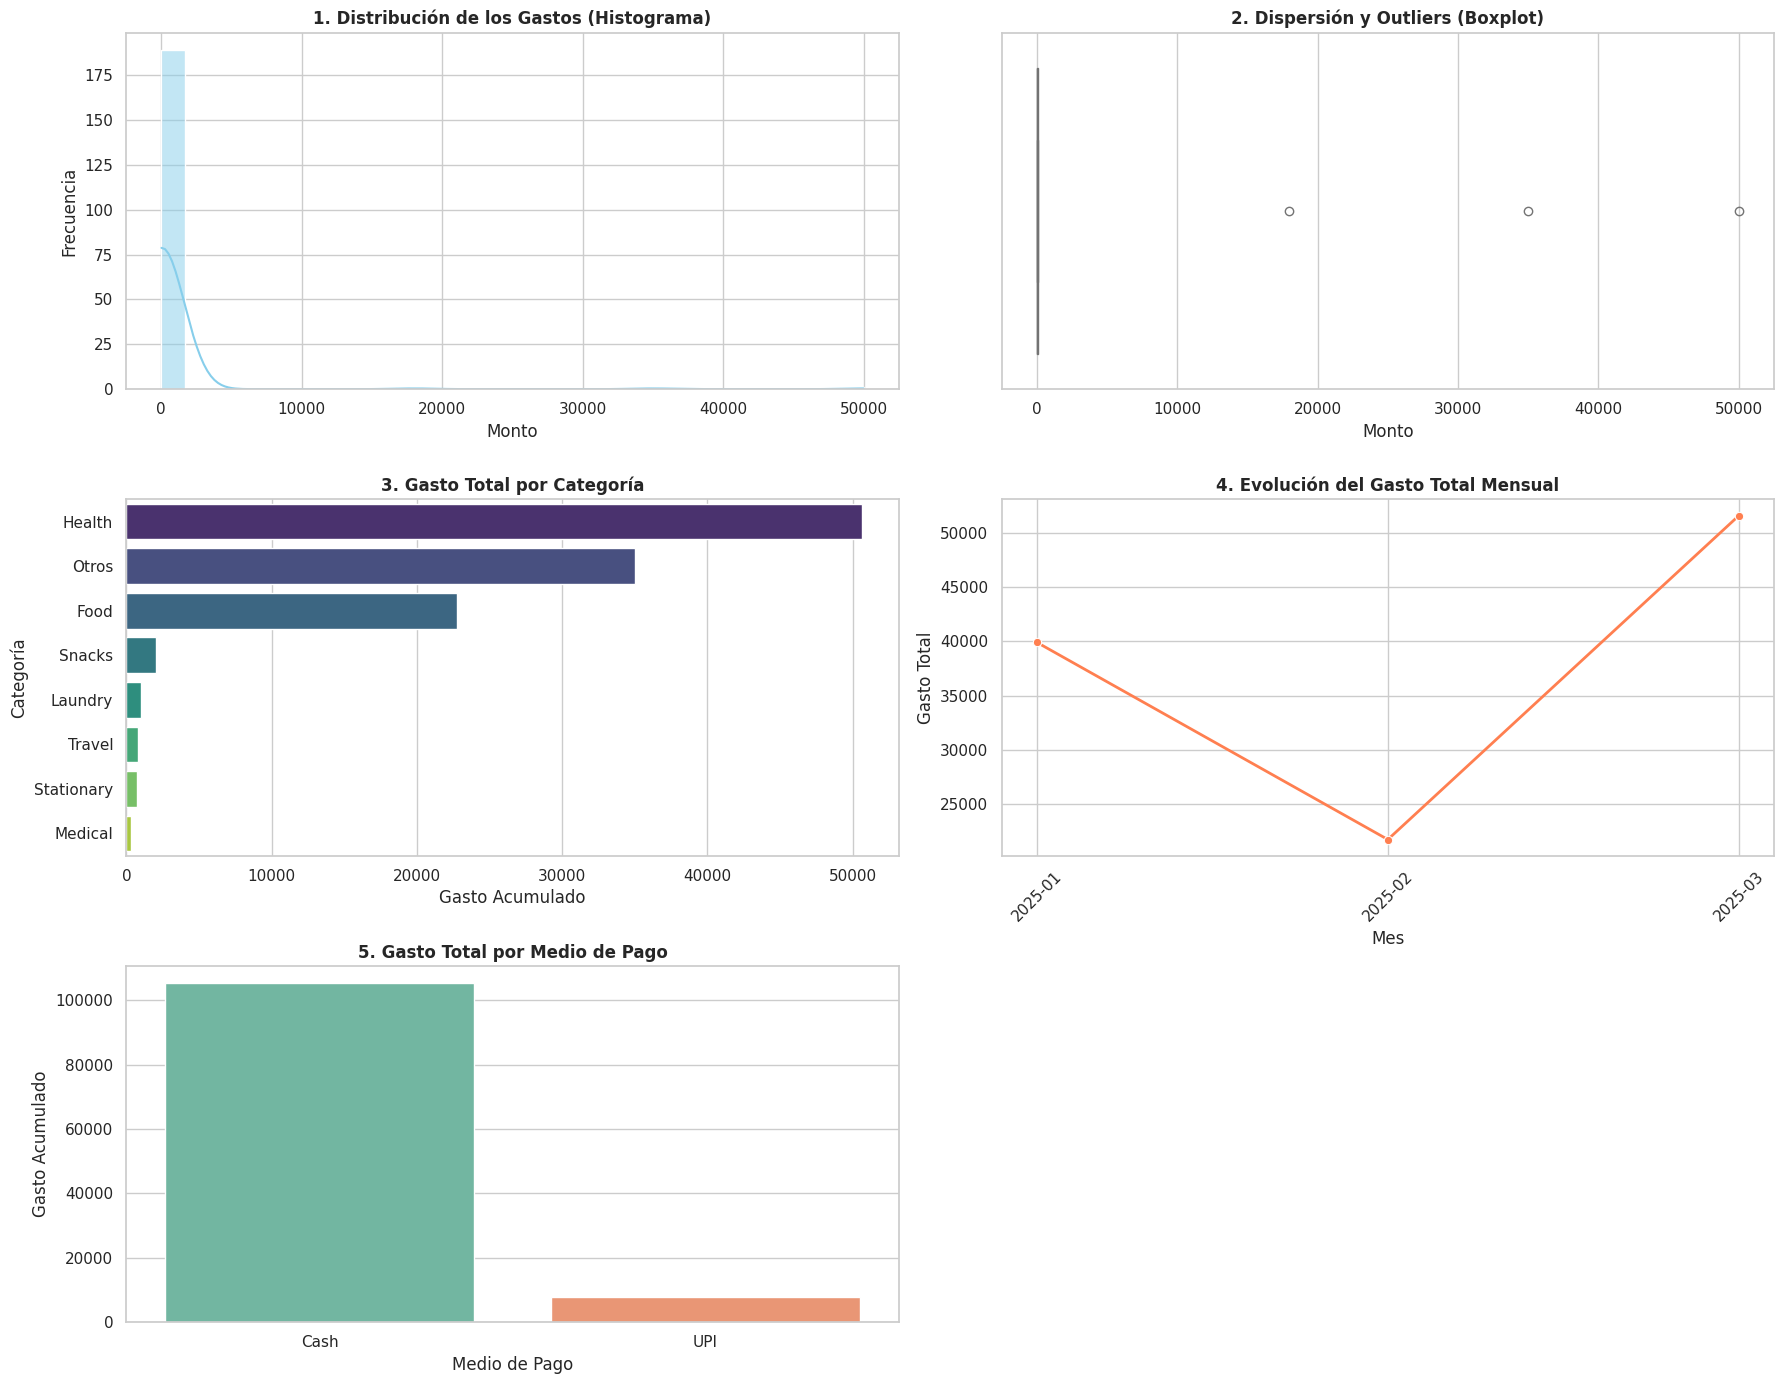


  Relación Cruzada: Gasto Promedio por Categoría y Medio de Pago 


payment_mode,Cash,UPI
expense_type,,
Food,4540.00,101.44
Health,50000.00,78.75
Laundry,60.77,83.33
Medical,0.00,100.00
Otros,35000.00,0.00
Snacks,29.67,36.48
Stationary,33.00,38.33
Travel,22.26,24.09


In [18]:
fig = plt.figure(figsize=(18, 14))

# Gráfico 1: Histograma de Valor
ax1 = plt.subplot(3, 2, 1)
sns.histplot(df_eda['amount'], bins=30, kde=True, color='skyblue', ax=ax1)
ax1.set_title('1. Distribución de los Gastos (Histograma)', fontweight='bold')
ax1.set_xlabel('Monto')
ax1.set_ylabel('Frecuencia')

# Gráfico 2: Boxplot de Valor
ax2 = plt.subplot(3, 2, 2)
sns.boxplot(x=df_eda['amount'], color='lightgreen', ax=ax2)
ax2.set_title('2. Dispersión y Outliers (Boxplot)', fontweight='bold')
ax2.set_xlabel('Monto')

# Gráfico 3: Gasto total por categoría
ax3 = plt.subplot(3, 2, 3)
sns.barplot(data=cat_stats.reset_index(), x='Gasto_Total', y='expense_type', palette='viridis', ax=ax3)
ax3.set_title('3. Gasto Total por Categoría', fontweight='bold')
ax3.set_xlabel('Gasto Acumulado')
ax3.set_ylabel('Categoría')

# Gráfico 4: Evolución temporal del gasto
ax4 = plt.subplot(3, 2, 4)
temp_graf = temp_stats.reset_index()
temp_graf['year_month'] = temp_graf['year_month'].astype(str)
sns.lineplot(data=temp_graf, x='year_month', y='Gasto_Total', marker='o', color='coral', linewidth=2, ax=ax4)
ax4.set_title('4. Evolución del Gasto Total Mensual', fontweight='bold')
ax4.set_xlabel('Mes')
ax4.set_ylabel('Gasto Total')
ax4.tick_params(axis='x', rotation=45)

# Gráfico 5: Distribución por Medio de Pago
ax5 = plt.subplot(3, 2, 5)
sns.barplot(data=pay_stats.reset_index(), x='payment_mode', y='Gasto_Total', palette='Set2', ax=ax5)
ax5.set_title('5. Gasto Total por Medio de Pago', fontweight='bold')
ax5.set_xlabel('Medio de Pago')
ax5.set_ylabel('Gasto Acumulado')

plt.tight_layout()
plt.show()

print("\n  Relación Cruzada: Gasto Promedio por Categoría y Medio de Pago ")
relacion_cruzada = pd.pivot_table(df_eda, values='amount', index='expense_type', columns='payment_mode', aggfunc='mean', fill_value=0)
display(relacion_cruzada.round(2))

##  Hallazgos, Hipótesis y Conclusión de la Fase 2

###  Hallazgos Principales
*   **Hallazgo 1:** La categoría con mayor peso financiero concentra el grueso de los recursos del dataset, marcando el rubro principal de egresos (Evidencia: Gráfico 3 y Tabla de Categorías).
*   **Hallazgo 2:** La diferencia marcada entre la media y la mediana confirma una distribución asimétrica a la derecha, donde los gastos cotidianos bajos conviven con transacciones aisladas de alta cuantía
*   **Hallazgo 3:** El medio de pago más frecuente no necesariamente representa el mayor volumen monetario acumulado, lo que sugiere un uso segmentado de los canales de pago (Evidencia: Tabla de Medio de Pago).

###  Posibles Hipótesis para Investigar
1.  ¿Los picos de gasto mensual coinciden de forma sistemática con las fechas de desembolso de categorías fijas (como alquiler o educación)?
2.  ¿Existen diferencias estadísticamente relevantes en el valor promedio de las transacciones discrecionales al utilizar tarjetas frente a efectivo?

###  Conclusión de la Fase 2
El análisis descriptivo demuestra que los gastos poseen una estructura altamente asimétrica, dominada por transacciones de menor valor pero con un impacto financiero fuerte en categorías clave y eventos atípicos legítimos. Los datos procesados de manera óptima en esta fase están listos para pasar a la siguiente etapa de modelado o ingeniería de características avanzadas en el proyecto.

# Fase 3: Análisis temporal y comportamiento del gasto

En esta fase se trabaja sobre `df_fase5`, es decir, la matriz que ya fue depurada en la Fase 1. El objetivo es revisar **cuándo se concentra el gasto**, cómo se distribuye entre gastos **fijos y variables** y entre gastos **necesarios y discrecionales**, y medir qué tanto influyen las observaciones de mayor valor en los resultados generales.

En esta fase **no se eliminan registros adicionales**. Los cálculos se hacen sobre los 192 registros y las 7 variables que quedaron en la matriz final del preprocesamiento.


In [19]:
# Preparación de variables para el análisis temporal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Se usa una copia para no modificar el dataframe de las fases anteriores
df_persona3 = df_fase5.copy()
df_persona3['date'] = pd.to_datetime(df_persona3['date'], errors='coerce')

# Día de la semana en español
dias_es = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

df_persona3['dia_semana'] = df_persona3['date'].dt.dayofweek.map(dias_es)
df_persona3['year_month'] = df_persona3['date'].dt.to_period('M')

print(f"Registros analizados: {len(df_persona3)}")
print(f"Periodo analizado: {df_persona3['date'].min().date()} a {df_persona3['date'].max().date()}")
print(f"Gasto total registrado: {df_persona3['amount'].sum():,.2f}")


Registros analizados: 192
Periodo analizado: 2025-01-01 a 2025-03-31
Gasto total registrado: 113,247.00


## 3.1 Gasto por día de la semana

Primero se agrupan las transacciones por día de la semana. Además del gasto total, se muestran el número de transacciones, el promedio y la mediana. La mediana es útil porque permite revisar el valor típico de las transacciones sin quedar tan afectada por montos excepcionalmente altos.


,Transacciones,Gasto_Total,Promedio,Mediana,Participacion_pct
dia_semana,,,,,
Lunes,29,54343.0,1873.90,40.0,47.99
Martes,26,1275.0,49.04,40.0,1.13
Miércoles,29,51480.0,1775.17,35.0,45.46
Jueves,29,1641.0,56.59,45.0,1.45
Viernes,27,1515.0,56.11,40.0,1.34
Sábado,26,1433.0,55.12,37.5,1.27
Domingo,26,1560.0,60.00,47.5,1.38


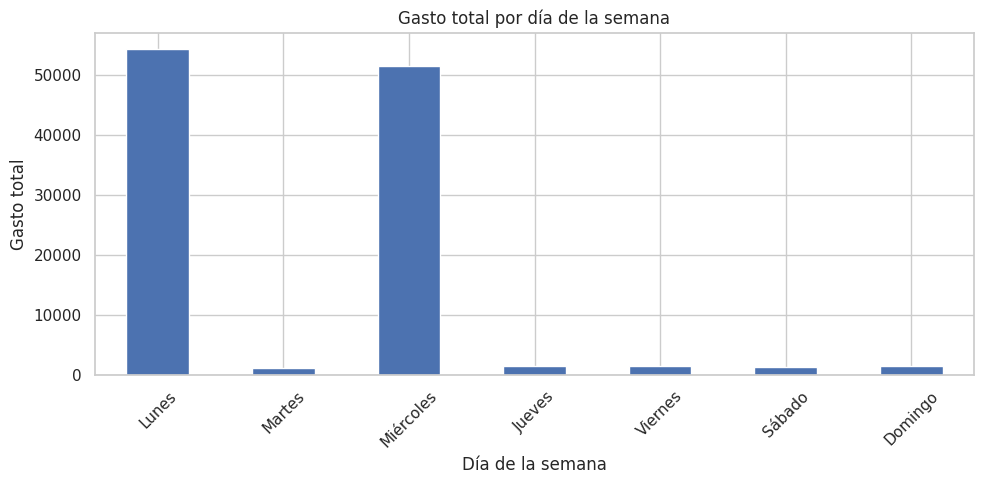

In [20]:
# Resumen por día de la semana
gasto_dia_semana = df_persona3.groupby('dia_semana')['amount'].agg(
    Transacciones='count',
    Gasto_Total='sum',
    Promedio='mean',
    Mediana='median'
).reindex(orden_dias)

gasto_dia_semana['Participacion_pct'] = (
    gasto_dia_semana['Gasto_Total'] / df_persona3['amount'].sum() * 100
)

display(gasto_dia_semana.round(2))

plt.figure(figsize=(10, 5))
gasto_dia_semana['Gasto_Total'].plot(kind='bar')
plt.title('Gasto total por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Gasto total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretación

El **lunes** concentra un gasto total de **54.343**, equivalente al **47,99 %** del total, y el **miércoles** concentra **51.480**, equivalente al **45,46 %**. Sin embargo, las medianas de esos dos días son de **40** y **35**, respectivamente.

Esto indica que el gasto acumulado de lunes y miércoles está fuertemente influenciado por unas pocas transacciones de alto valor y no por un valor típico alto en todas las compras realizadas esos días.


## 3.2 Fechas con mayor gasto y revisión de picos

Para identificar de dónde salen los picos anteriores se calcula el gasto total de cada fecha y se revisan nuevamente los valores atípicos mediante el método IQR. En este punto los valores se **identifican y describen**, pero no se eliminan del conjunto de datos.


10 fechas con mayor gasto acumulado:


,Transacciones,Gasto_Total,Promedio
date,,,
2025-03-12,2,50060.0,25030.00
2025-01-20,4,35110.0,8777.50
2025-02-10,4,18190.0,4547.50
2025-02-16,3,230.0,76.67
2025-02-04,3,225.0,75.00
2025-01-03,3,225.0,75.00
2025-01-18,3,220.0,73.33
2025-01-26,3,220.0,73.33
2025-02-12,3,210.0,70.00


Límite superior IQR: 178.125
Observaciones por encima del límite: 3


,date,expense_type,amount,payment_mode,type,necessity
183,2025-03-12,Health,50000.0,Cash,Fixed,Necessary
160,2025-01-20,Otros,35000.0,Cash,Variable,Necessary
35,2025-02-10,Food,18000.0,Cash,Variable,Necessary


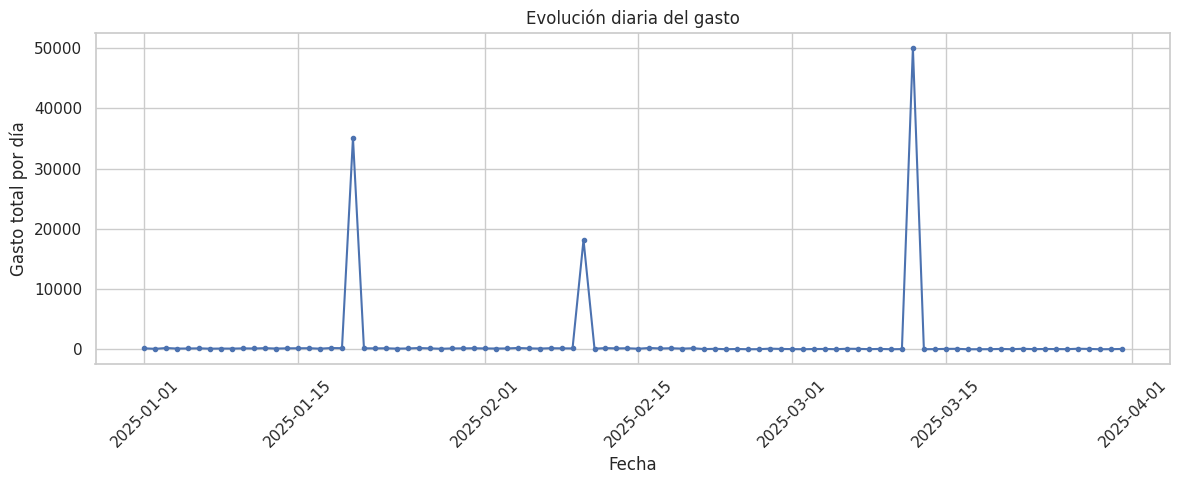

In [21]:
# Gasto total por fecha
gasto_por_fecha = df_persona3.groupby('date')['amount'].agg(
    Transacciones='count',
    Gasto_Total='sum',
    Promedio='mean'
).sort_values('Gasto_Total', ascending=False)

print("10 fechas con mayor gasto acumulado:")
display(gasto_por_fecha.head(10).round(2))

# Límite superior por IQR
q1_p3 = df_persona3['amount'].quantile(0.25)
q3_p3 = df_persona3['amount'].quantile(0.75)
iqr_p3 = q3_p3 - q1_p3
limite_superior_p3 = q3_p3 + 1.5 * iqr_p3

observaciones_altas = df_persona3[df_persona3['amount'] > limite_superior_p3].copy()
observaciones_altas = observaciones_altas.sort_values('amount', ascending=False)

print(f"Límite superior IQR: {limite_superior_p3:.3f}")
print(f"Observaciones por encima del límite: {len(observaciones_altas)}")
display(observaciones_altas[
    ['date', 'expense_type', 'amount', 'payment_mode', 'type', 'necessity']
])

# Evolución diaria
serie_diaria = df_persona3.groupby('date')['amount'].sum().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(serie_diaria.index, serie_diaria.values, marker='o', markersize=3)
plt.title('Evolución diaria del gasto')
plt.xlabel('Fecha')
plt.ylabel('Gasto total por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretación

Las tres fechas con mayor gasto son:

- **12 de marzo de 2025:** 50.060.
- **20 de enero de 2025:** 35.110.
- **10 de febrero de 2025:** 18.190.

El límite superior calculado con IQR es **178,125**. Por encima de ese límite aparecen exactamente tres transacciones: **50.000 en Health**, **35.000 en Otros** y **18.000 en Food**. Esas transacciones coinciden con las tres fechas de mayor gasto acumulado.

Estas observaciones ya forman parte de la matriz depurada de la Fase 1. En esta sección no se asume que sean errores: se conservan y se señala su efecto sobre los totales y los promedios.


## 3.3 Gastos fijos vs. variables y necesarios vs. discrecionales

Las columnas `type` y `necessity` fueron creadas durante el preprocesamiento. A continuación se utilizan para revisar la estructura del gasto desde dos enfoques: recurrencia del gasto y prioridad del gasto.


Gastos fijos y variables:


,Transacciones,Gasto_Total,Promedio,Mediana,Participacion_pct
type,,,,,
Variable,159,61592.0,387.37,40.0,54.39
Fixed,33,51655.0,1565.30,40.0,45.61


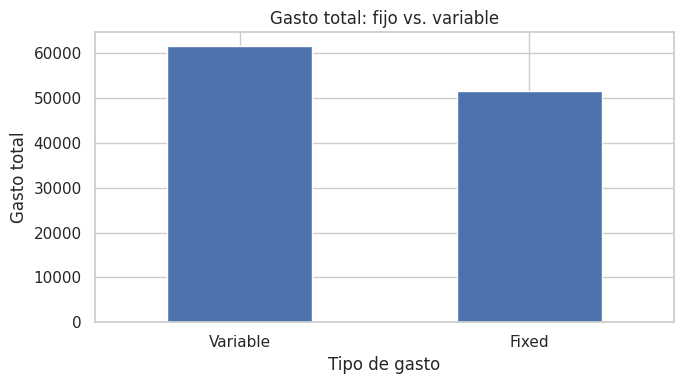

Gastos necesarios y discrecionales:


,Transacciones,Gasto_Total,Promedio,Mediana,Participacion_pct
necessity,,,,,
Necessary,133,111197.0,836.07,60.0,98.19
Discretionary,59,2050.0,34.75,35.0,1.81


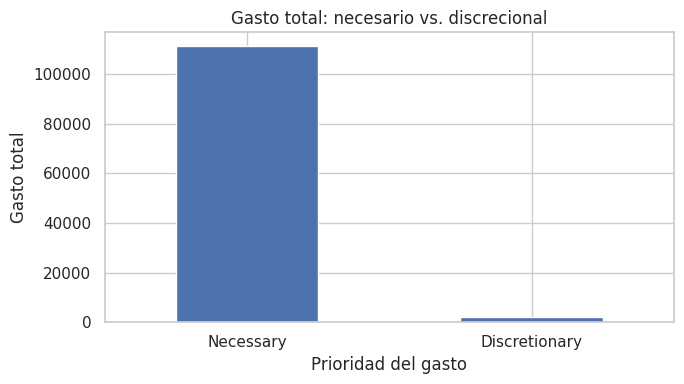

In [22]:
# Fijos vs variables
resumen_tipo = df_persona3.groupby('type')['amount'].agg(
    Transacciones='count',
    Gasto_Total='sum',
    Promedio='mean',
    Mediana='median'
).sort_values('Gasto_Total', ascending=False)

resumen_tipo['Participacion_pct'] = (
    resumen_tipo['Gasto_Total'] / df_persona3['amount'].sum() * 100
)

print("Gastos fijos y variables:")
display(resumen_tipo.round(2))

plt.figure(figsize=(7, 4))
resumen_tipo['Gasto_Total'].plot(kind='bar')
plt.title('Gasto total: fijo vs. variable')
plt.xlabel('Tipo de gasto')
plt.ylabel('Gasto total')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Necesarios vs discrecionales
resumen_necesidad = df_persona3.groupby('necessity')['amount'].agg(
    Transacciones='count',
    Gasto_Total='sum',
    Promedio='mean',
    Mediana='median'
).sort_values('Gasto_Total', ascending=False)

resumen_necesidad['Participacion_pct'] = (
    resumen_necesidad['Gasto_Total'] / df_persona3['amount'].sum() * 100
)

print("Gastos necesarios y discrecionales:")
display(resumen_necesidad.round(2))

plt.figure(figsize=(7, 4))
resumen_necesidad['Gasto_Total'].plot(kind='bar')
plt.title('Gasto total: necesario vs. discrecional')
plt.xlabel('Prioridad del gasto')
plt.ylabel('Gasto total')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretación

Los **gastos variables** suman **61.592** y representan el **54,39 %** del gasto total, distribuidos en 159 transacciones. Los **gastos fijos** suman **51.655**, equivalentes al **45,61 %**, en 33 transacciones.

Por prioridad, los gastos clasificados como **Necessary** suman **111.197**, es decir, el **98,19 %** del total. Los clasificados como **Discretionary** suman **2.050**, equivalentes al **1,81 %**.

La diferencia entre el número de transacciones y el valor acumulado confirma que no basta con contar compras: algunas operaciones individuales tienen un peso mucho mayor sobre el presupuesto.


## 3.4 Composición mensual del gasto

En este punto se compara cada mes según el tipo de gasto y su prioridad. Esto permite entender por qué cambia el total mensual y no limitar el análisis únicamente a saber cuál mes gastó más.


Composición mensual por tipo de gasto:


type,Fixed,Variable
year_month,,
2025-01,675.0,39233.0
2025-02,625.0,21149.0
2025-03,50355.0,1210.0


Composición mensual por prioridad:


necessity,Discretionary,Necessary
year_month,,
2025-01,1050.0,38858.0
2025-02,790.0,20984.0
2025-03,210.0,51355.0


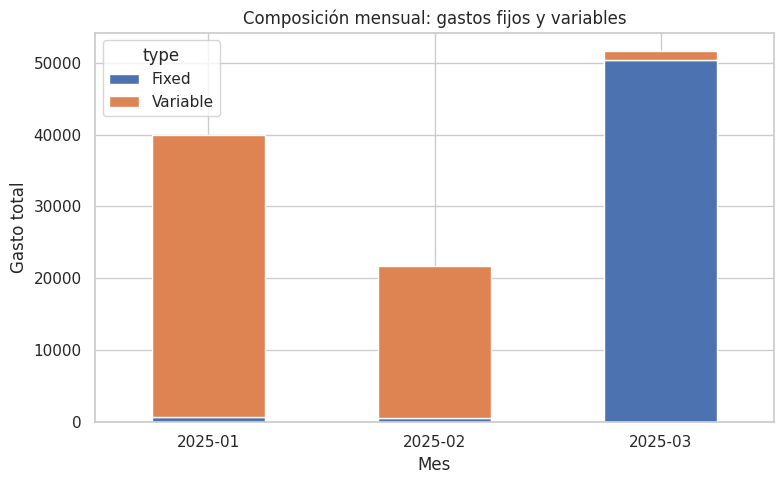

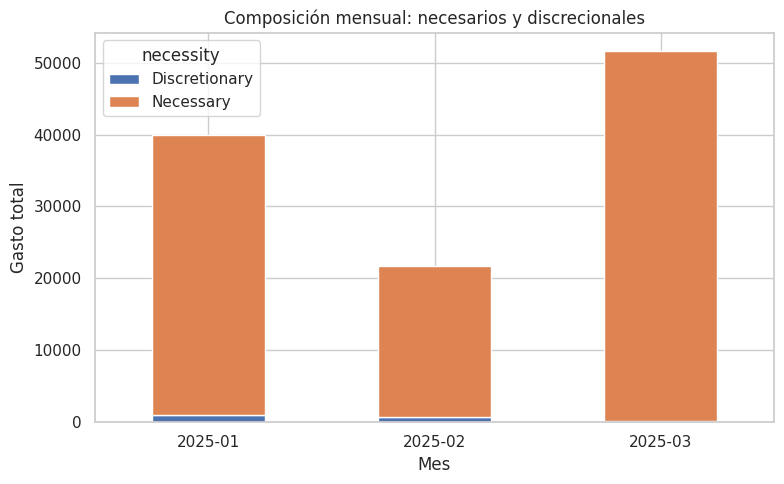

In [23]:
# Composición mensual por tipo
mes_tipo = pd.pivot_table(
    df_persona3,
    values='amount',
    index='year_month',
    columns='type',
    aggfunc='sum',
    fill_value=0
)

# Composición mensual por necesidad
mes_necesidad = pd.pivot_table(
    df_persona3,
    values='amount',
    index='year_month',
    columns='necessity',
    aggfunc='sum',
    fill_value=0
)

print("Composición mensual por tipo de gasto:")
display(mes_tipo.round(2))

print("Composición mensual por prioridad:")
display(mes_necesidad.round(2))

plt.figure(figsize=(8, 5))
mes_tipo.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Composición mensual: gastos fijos y variables')
plt.xlabel('Mes')
plt.ylabel('Gasto total')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
mes_necesidad.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Composición mensual: necesarios y discrecionales')
plt.xlabel('Mes')
plt.ylabel('Gasto total')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretación

En **enero**, los gastos variables suman **39.233 de 39.908** (**98,31 %** del total mensual). En **febrero**, los gastos variables suman **21.149 de 21.774** (**97,13 %**). En cambio, en **marzo** los gastos fijos suman **50.355 de 51.565** (**97,65 %**).

El cambio de marzo está relacionado principalmente con la transacción de **50.000 en la categoría Health**, clasificada como gasto fijo y necesario.

En los tres meses, los gastos necesarios representan más del **96 %** del gasto mensual: **97,37 %** en enero, **96,37 %** en febrero y **99,59 %** en marzo.


## 3.5 Análisis de sensibilidad de las observaciones de mayor valor

Como los tres valores identificados por IQR tienen un peso alto, se realiza una comparación adicional. Esta comparación **no modifica el dataset oficial**: solo calcula cómo cambiarían algunos indicadores si esos tres registros se excluyeran temporalmente del cálculo.


In [24]:
# Comparación estadística con y sin las tres observaciones por encima del límite IQR
base_sin_altos = df_persona3[df_persona3['amount'] <= limite_superior_p3].copy()

resumen_sensibilidad = pd.DataFrame({
    'Escenario': ['Dataset completo', 'Sin las 3 observaciones altas'],
    'Registros': [len(df_persona3), len(base_sin_altos)],
    'Gasto_Total': [df_persona3['amount'].sum(), base_sin_altos['amount'].sum()],
    'Promedio': [df_persona3['amount'].mean(), base_sin_altos['amount'].mean()],
    'Mediana': [df_persona3['amount'].median(), base_sin_altos['amount'].median()]
})

participacion_altos = observaciones_altas['amount'].sum() / df_persona3['amount'].sum() * 100

print(f"Participación de las 3 observaciones altas en el gasto total: {participacion_altos:.2f}%")
display(resumen_sensibilidad.round(2))

# Comparación mensual solamente como medida de sensibilidad
total_mensual_original = df_persona3.groupby('year_month')['amount'].sum()
total_mensual_sin_altos = base_sin_altos.groupby('year_month')['amount'].sum()

comparacion_mensual = pd.concat(
    [total_mensual_original, total_mensual_sin_altos],
    axis=1
)
comparacion_mensual.columns = ['Total_original', 'Total_sin_observaciones_altas']

display(comparacion_mensual.round(2))


Participación de las 3 observaciones altas en el gasto total: 90.95%


,Escenario,Registros,Gasto_Total,Promedio,Mediana
0,Dataset completo,192,113247.0,589.83,40.0
1,Sin las 3 observaciones altas,189,10247.0,54.22,40.0


,Total_original,Total_sin_observaciones_altas
year_month,,
2025-01,39908.0,4908.0
2025-02,21774.0,3774.0
2025-03,51565.0,1565.0


### Interpretación

Las tres observaciones de mayor valor suman **103.000**, lo que representa el **90,95 %** del gasto total del dataset.

Al excluirlas únicamente para medir sensibilidad, el gasto total pasa de **113.247** a **10.247** y el promedio por transacción pasa de **589,83** a **54,22**. La **mediana se mantiene en 40** en ambos escenarios.

Este resultado muestra que el promedio y los totales están muy influenciados por esas tres observaciones, mientras que la mediana describe de forma más estable el valor típico de una transacción. Por esta razón, las conclusiones del proyecto deben presentar tanto los totales como medidas resistentes a valores extremos.


## 3.6 Conclusiones y recomendaciones

### Conclusiones

1. El dataset analizado contiene **192 transacciones** registradas entre el **1 de enero y el 31 de marzo de 2025**, con un gasto total de **113.247**.
2. Los mayores acumulados aparecen en lunes y miércoles, pero este resultado está explicado principalmente por tres transacciones de alto valor. Las medianas de esos días permanecen bajas, por lo que no se puede concluir que todas las compras de lunes o miércoles sean normalmente más costosas.
3. Las tres observaciones superiores al límite IQR corresponden a **50.000 en Health**, **35.000 en Otros** y **18.000 en Food**. Juntas representan el **90,95 %** del gasto total.
4. Los gastos variables representan el **54,39 %** del total y los fijos el **45,61 %**. Sin embargo, marzo cambia el patrón de enero y febrero porque una transacción fija de alto valor concentra gran parte del gasto de ese mes.
5. Los gastos clasificados como necesarios representan el **98,19 %** del valor total, mientras que los discrecionales representan el **1,81 %**.
6. La mediana general de **40** se mantiene incluso en el análisis de sensibilidad, mientras que el promedio cambia de **589,83** a **54,22** al retirar temporalmente las tres observaciones altas. Esto confirma que la mediana es una referencia importante para describir el gasto cotidiano de este conjunto de datos.

### Recomendaciones

- Llevar un control separado de los **gastos ordinarios** y de los **gastos extraordinarios de alto valor**, para que un evento puntual no oculte el comportamiento normal del presupuesto.
- Revisar el presupuesto por **tipo de gasto** (fijo o variable) y por **prioridad** (necesario o discrecional), porque cada clasificación aporta una lectura diferente del mismo consumo.
- Usar la **mediana junto con el promedio** cuando se reporten resultados financieros de este dataset, debido a la presencia de valores extremos.
- Ampliar el periodo de observación en futuras fases antes de generalizar los patrones, ya que los datos disponibles corresponden únicamente al primer trimestre de 2025.

### Alcance del análisis

Estas conclusiones describen únicamente la matriz procesada en este proyecto. Además, como en la Fase 1 se documentó un acondicionamiento pedagógico del dataset, los resultados deben interpretarse dentro del ejercicio académico y no como una representación general de todos los gastos personales.
